In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter

In [6]:
mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed

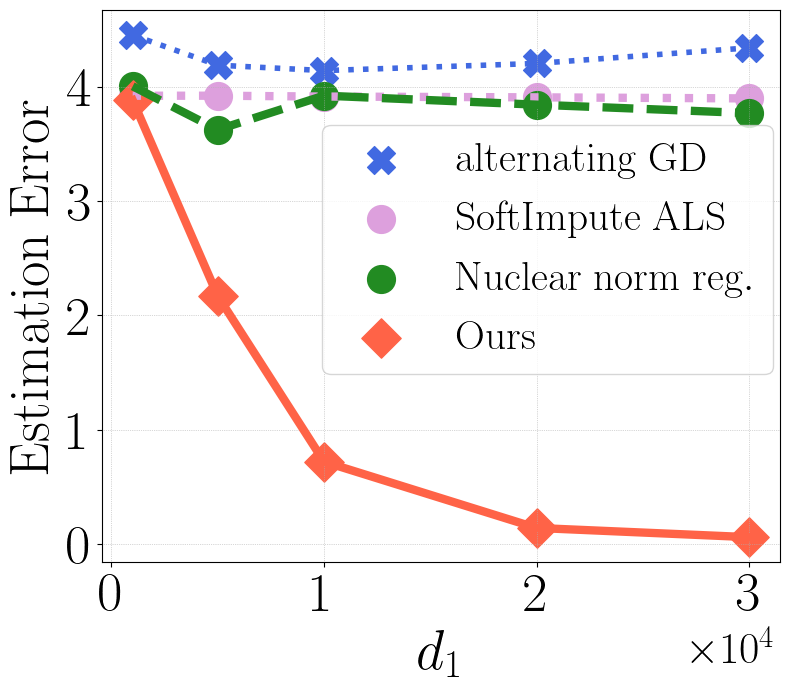

In [14]:
# title = r'$\mathrm{Synthetic~(2~obervations)}$'
d1 = [1000, 5000, 10000, 20000, 30000]
alt_GD = np.array([4.4501028, 4.1873474, 4.1397815, 4.2022367, 4.3389158])
softimpute_als = np.array([3.9199268, 3.9201284, 3.9127384, 3.9058255, 3.8966076])
nuclear_reg = np.array([4.0026073, 3.6227927, 3.9208028, 3.8417674, 3.7678982])
iipw_1 = np.array([3.9895393, 3.9368068, 3.8819335, 3.7691855, 3.6639122])
iipw = np.array([3.8805952, 2.1690504, 0.7195714, 0.1405762, 0.0598621])

f, ax = plt.subplots(figsize=(8,7))

#enhance = ob2_rmse_mean / rmse_mean
#enhance = rmse_mean / ob2_rmse_mean
#print(enhance.mean())
#print(ob2_err_mean)
#print(err_mean)

plt.plot(d1, alt_GD, lw=4, color='royalblue',ls="dotted" )
plt.plot(d1, softimpute_als, lw=6, color='plum', ls="dotted")
plt.plot(d1, nuclear_reg, lw=6, color='forestgreen', ls="dashed")
plt.plot(d1, iipw, color='tomato',lw=6)

plt.scatter(d1, alt_GD, s=400, color='royalblue', label=r"$\mathrm{alternating~GD}$", marker="X")
plt.scatter(d1, softimpute_als, s=400, color='plum', label=r"$\mathrm{SoftImpute~ALS}$", marker="o")
plt.scatter(d1, nuclear_reg, s=400, color='forestgreen', label=r"$\mathrm{Nuclear~norm~reg.}$")
plt.scatter(d1, iipw, s=400, color='tomato', label=r"$\mathrm{Ours}$", marker="D")

plt.legend(fontsize=30, loc='upper right', bbox_to_anchor=(1.02, 0.83))

plt.xlabel(r"$d_1$", fontsize=40)
plt.ylabel(r"$\mathrm{Estimation~Error}$", fontsize=40)

xticks = [0, 10000, 20000, 30000]
plt.xticks(xticks, fontsize=40)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')
plt.yticks(fontsize=40)
ax.xaxis.get_offset_text().set_fontsize(32)

plt.grid(lw=0.5, ls=":")
plt.tight_layout()
plot_name = f"two_per_row_err.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

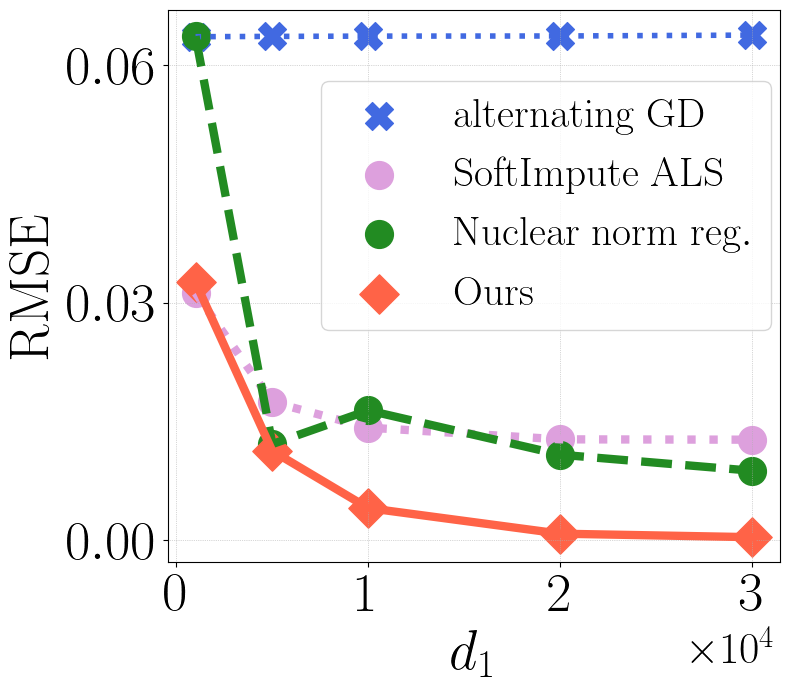

In [18]:
# observed entries
d1 = [1000, 5000, 10000, 20000, 30000]
alt_GD_rmse = np.array([0.0636046, 0.0636437, 0.0636801, 0.0636962, 0.0638076])
softimpute_als_rmse = np.array([0.0312063, 0.0174234, 0.0141976, 0.0127178, 0.0126747])
nuclear_reg_rmse = np.array([0.0636746, 0.0121213, 0.0163727, 0.0107768, 0.0087501])
iipw_1_rmse = np.array([0.0497238, 0.0205959, 0.0140485, 0.0097816, 0.0077941])
iipw_rmse = np.array([0.0325514, 0.0112466, 0.0040286, 0.0007947, 0.0003541])

f, ax = plt.subplots(figsize=(8,7))

plt.plot(d1, alt_GD_rmse, lw=4, color='royalblue',ls="dotted" )
plt.plot(d1, softimpute_als_rmse, lw=6, color='plum', ls="dotted")
plt.plot(d1, nuclear_reg_rmse, lw=6, color='forestgreen', ls="dashed")
plt.plot(d1, iipw_rmse, color='tomato',lw=6)

plt.scatter(d1, alt_GD_rmse, s=400, color='royalblue', label=r"$\mathrm{alternating~GD}$", marker="X")
plt.scatter(d1, softimpute_als_rmse, s=400, color='plum', label=r"$\mathrm{SoftImpute~ALS}$", marker="o")
plt.scatter(d1, nuclear_reg_rmse, s=400, color='forestgreen', label=r"$\mathrm{Nuclear~norm~reg.}$")
plt.scatter(d1, iipw_rmse, s=400, color='tomato', label=r"$\mathrm{Ours}$", marker="D")

plt.legend(fontsize=30, loc='upper right', bbox_to_anchor=(1.02, 0.91))

plt.xlabel(r"$d_1$", fontsize=40)
plt.ylabel(r"$\mathrm{RMSE}$", fontsize=40)

xticks = [0, 10000, 20000, 30000]
plt.xticks(xticks, fontsize=40)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')

ax.xaxis.get_offset_text().set_fontsize(32)

#plt.yticks([0.5, 1.0, 1.5], fontsize=40)
plt.yticks([0, 0.03, 0.06], fontsize=40)
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((4, 4))

plt.grid(lw=0.5, ls=":")
plt.tight_layout()
plot_name = f"two_per_row_rmse.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()